# Financial News EDA - Sentiment & Market Impact Analysis

This notebook explores financial news headlines to understand publishing patterns, key publishers, and textual characteristics. The goal is to prepare the dataset for sentiment and stock correlation analysis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()

df.info()
df.describe()

df.isnull().sum()

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['date'].min(), df['date'].max()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


(Timestamp('2011-04-27 21:01:48-0400', tz='UTC-04:00'),
 Timestamp('2020-06-11 17:12:35-0400', tz='UTC-04:00'))

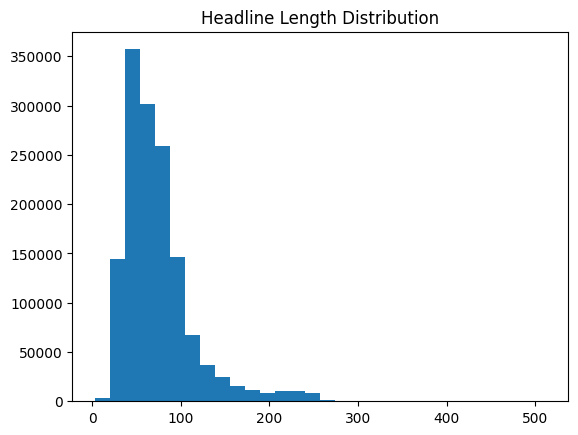

In [3]:
df['headline_length'] = df['headline'].apply(len)
df['headline_length'].describe()

plt.hist(df['headline_length'], bins=30)
plt.title("Headline Length Distribution")
plt.show()

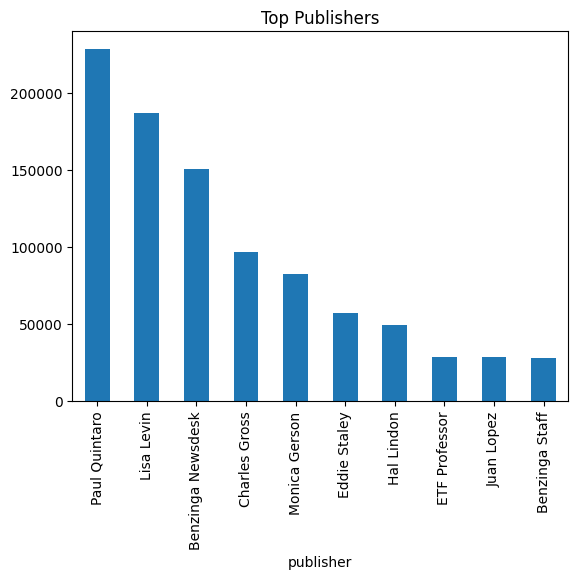

In [4]:
top_publishers = df['publisher'].value_counts().head(10)
top_publishers

top_publishers.plot(kind='bar')
plt.title("Top Publishers")
plt.show()

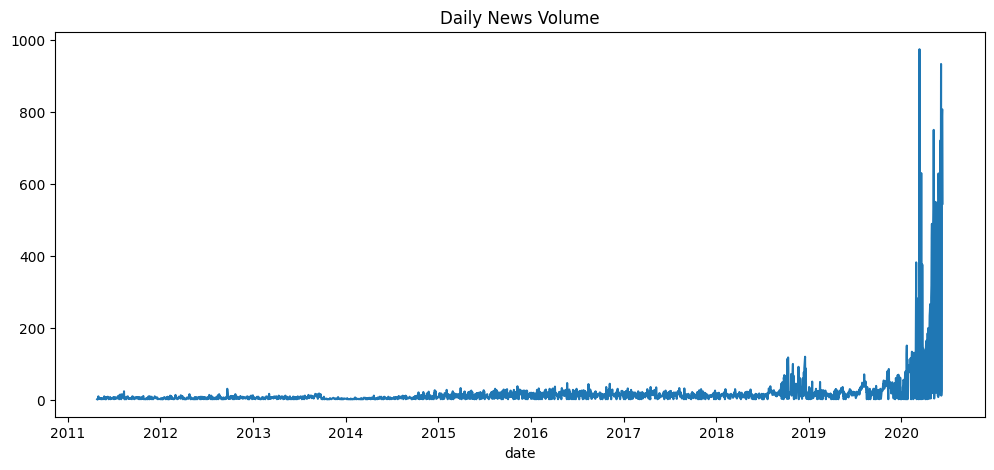

In [5]:
daily_news = df.groupby(df['date'].dt.date).size()
daily_news.plot(figsize=(12,5))
plt.title("Daily News Volume")
plt.show()

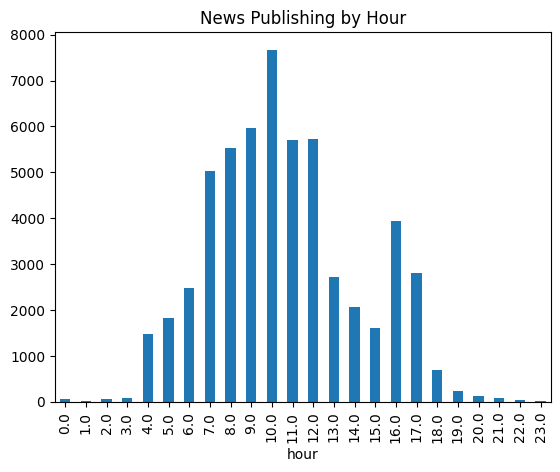

In [6]:
df['hour'] = df['date'].dt.hour
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("News Publishing by Hour")
plt.show()

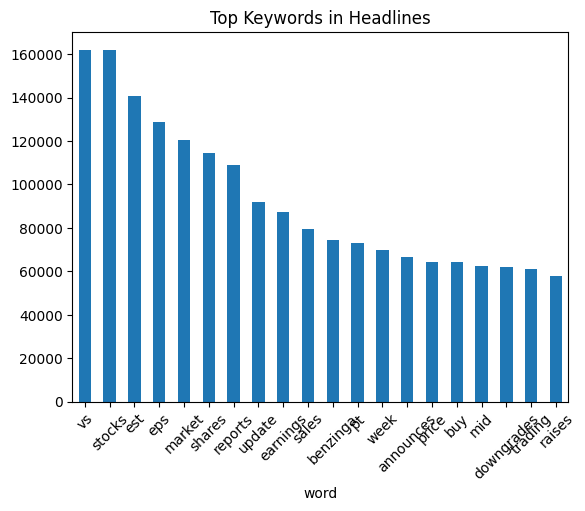

In [7]:
df['headline'] = df['headline'].astype(str)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['headline'])

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

word_freq = pd.DataFrame({
    'word': words,
    'count': counts
}).sort_values(by='count', ascending=False)

word_freq

word_freq.plot(kind='bar', x='word', y='count', legend=False)
plt.title("Top Keywords in Headlines")
plt.xticks(rotation=45)
plt.show()

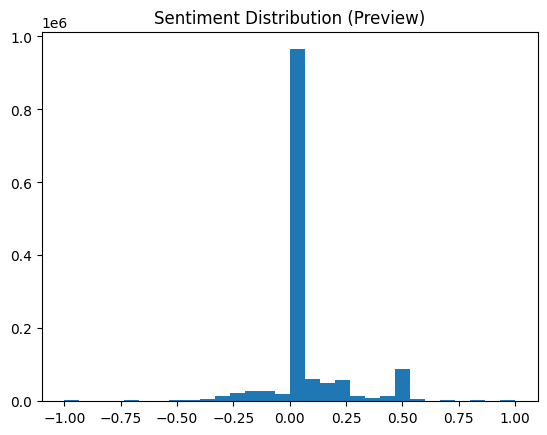

In [8]:
from textblob import TextBlob

df['sentiment'] = df['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['sentiment'].describe()

plt.hist(df['sentiment'], bins=30)
plt.title("Sentiment Distribution (Preview)")
plt.show()


# Key Insights

- Headlines are mostly short and structured for fast consumption.
- Certain publishers dominate news production.
- News volume spikes suggest correlation with market events.
- Common keywords indicate financial themes like earnings, upgrades, and price targets.